In [ ]:
import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt
#from jinja2 import Template
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict #train_test_split,
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, recall_score, precision_score, f1_score,roc_curve, silhouette_score, precision_recall_curve, average_precision_score
from xgboost import XGBClassifier
from sklearn.inspection import permutation_importance
import plotly.graph_objects as go
import plotly.express as px
import numpy as np
import shap

In [15]:
# =========================
# DATA LOADING
# =========================
path = kagglehub.dataset_download(
    "blastchar/telco-customer-churn"
)

csv_path = os.path.join(
    path,
    "WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

df = pd.read_csv(csv_path)

Data Cleaning
Converting TotalCharges to numeric and removing NaN values (only 11 present in set.)
Establish dummy variables for categorical columns and prepare x_raw by removing target variable and ID.

In [16]:
# =========================
# DATA CLEANING
# =========================

original_rows = len(df)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

missing_totalcharges = df['TotalCharges'].isna().sum()

df = df.dropna()

final_rows = len(df)

df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

categorical_cols = df.select_dtypes(include=['object','str']).columns
categorical_cols = categorical_cols.drop('customerID')
df_encoded = pd.get_dummies(df, columns=list(categorical_cols), drop_first=True)

x_raw = df_encoded.drop('Churn', axis=1)
x_raw = x_raw.drop(['customerID', 'TotalCharges'], axis=1)


cleaning_summary = pd.DataFrame({
    "Metric": [
        "Rows Before Cleaning",
        "Rows After Cleaning",
        "Rows Removed",
        "Missing TotalCharges"
    ],
    "Value": [
        original_rows,
        final_rows,
        original_rows - final_rows,
        missing_totalcharges
    ]
})

display(cleaning_summary)



,Metric,Value
0,Rows Before Cleaning,7043
1,Rows After Cleaning,7032
2,Rows Removed,11
3,Missing TotalCharges,11


Clustering
Data is scaled and PCA to allow for simple clustering visualization. PCA is NOT currently used in modeling to preserve model explainability to business stakeholders.

Uses kmeans cluster for determining cluster size, normalized churn rates, total revenue by cluster, and average tenure by cluster.

A division of 3 clusters was chosen based on the Elbow/Silhouette results.



Text(0, 0.5, 'Average Silhouette Score')

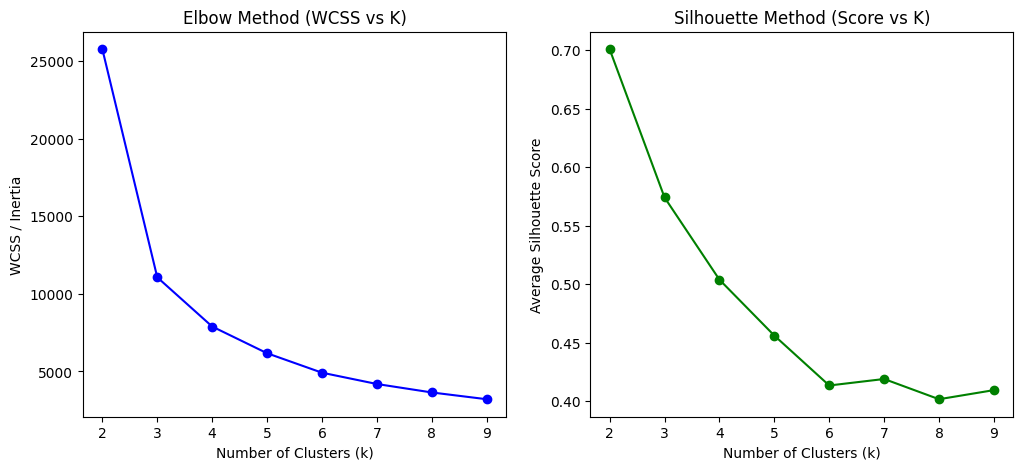

In [17]:
# =========================
# FEATURE ENGINEERING
# =========================
cluster_features = StandardScaler().fit_transform(x_raw)
pca = PCA(n_components = 2)
x_pca = pca.fit_transform(cluster_features)
y = df['Churn']
x_cluster = x_pca

wcss = []
silhouette_scores = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=123)
    kmeans.fit(x_cluster)
    labels = kmeans.labels_
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(x_cluster, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Elbow Method Plot
ax1.plot(k_range, wcss, marker='o', color='blue')
ax1.set_title('Elbow Method (WCSS vs K)')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('WCSS / Inertia')

# Silhouette Method Plot
ax2.plot(k_range, silhouette_scores, marker='o', color='green')
ax2.set_title('Silhouette Method (Score vs K)')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Average Silhouette Score')


Based on the elbow chart and business interpretability, I selected 3 clusters for customer segmentation. The silhouette score is highest at k=2, so k=3 should be interpreted as a practical segmentation choice rather than a purely score-maximizing choice.

Cluster profiles were derived using unsupervised PCA space. Churn rates are discussed post-hoc for interpretation and were not used for model training.

Analysis:
- Cluster 1 is the largest and highest-risk segment, with 3,183 customers, a 45.1% churn rate, approximately $3.85M in total revenue, and average tenure of 17.2 months.
- Cluster 2 is the highest-value stable segment, with 2,329 customers, a 13.7% churn rate, approximately $11.19M in total revenue, and average tenure of 54.4 months.
- Cluster 0 is the lowest-revenue, lowest-churn segment, with 1,520 customers, a 7.4% churn rate, approximately $1.01M in total revenue, and average tenure of 30.7 months.

,Number_of_Customers
Cluster,
1,3183
2,2329
0,1520


Churn,No Churn,Churn
Cluster,,
1,55.0,45.0
2,86.0,14.0
0,93.0,7.0


,Total_Revenue
Cluster,
2,"$11,192,449.90"
1,"$3,852,583.90"
0,"$1,011,134.90"


,Avg_Tenure
Cluster,
2,54.4 months
0,30.7 months
1,17.2 months


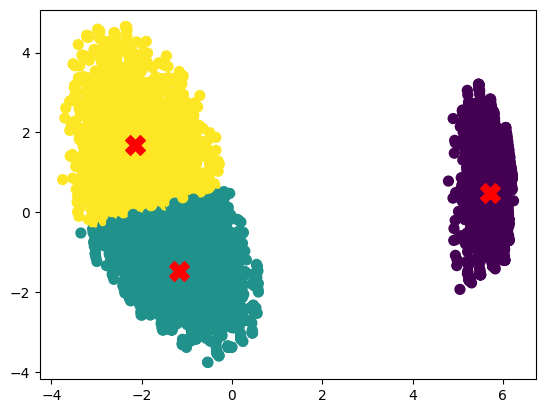

In [18]:
# =========================
# CLUSTERING ANALYSIS
# =========================
kmeans = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=123)
y_kmeans = kmeans.fit_predict(x_cluster)

cluster_df = df.copy()
cluster_df['Cluster'] = y_kmeans

display(
        cluster_df.groupby('Cluster')
        .agg(Number_of_Customers=('Cluster','count'))
        .sort_values(['Number_of_Customers'], ascending=False)
        )

churn_rate_by_cluster = (
    cluster_df.groupby("Cluster")["Churn"]
    .value_counts(normalize=True)
    .round(2)
    .mul(100)
    .unstack()
    .rename(columns={0: "No Churn", 1: "Churn"})
    .sort_values(by="Churn", ascending=False)
)

display(churn_rate_by_cluster)

display(
    cluster_df.groupby('Cluster')
    .agg(Total_Revenue=('TotalCharges','sum'))
    .sort_values(['Total_Revenue'], ascending=False) 
    .style.format({'Total_Revenue': '${:,.2f}'})
        
        
    )

display(
    cluster_df.groupby('Cluster')
    .agg(Avg_Tenure=('tenure','mean'))
    .sort_values(['Avg_Tenure'], ascending=False)
         .style.format({'Avg_Tenure': '{:.1f} months'})
)

plt.scatter(x_cluster[:, 0], x_cluster[:, 1], c=y_kmeans, s=50, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='red', marker='X')
plt.show()

cluster_summary = (
    cluster_df
    .groupby('Cluster')
    .agg(
        Customers=('Churn', 'count'),
        ChurnRate=('Churn', 'mean')
    )
    .reset_index()
)

cluster_summary['ChurnRate'] *= 100

rev_summary = (
    cluster_df
    .groupby('Cluster')
    .agg(Total_Revenue=('TotalCharges', 'sum'))
    .reset_index()
)

rev_summary['Revenue_Label'] = (
    rev_summary['Total_Revenue'] / 1000
).round(1).astype(str) + 'K'

avg_charges_summary = (
    cluster_df
    .groupby('Cluster')
    .agg(Avg_Charges=('MonthlyCharges', 'mean'))
    .reset_index()
)

avg_tenure_summary = (
    cluster_df
    .groupby('Cluster')
    .agg(Avg_Tenure=('tenure', 'mean'))
    .reset_index()
)

fig = px.bar(
    cluster_summary,
    x='Cluster',
    y='ChurnRate',
    text='ChurnRate',
    title='Customer Churn Rate by Cluster'
)

fig.update_traces(
    texttemplate='%{text:.1f}%',
    textposition='auto'
)

fig.update_layout(
        yaxis_range=[
        0,
        cluster_summary['ChurnRate'].max() * 1.15
    ],
    yaxis_title='Churn Rate (%)',
    xaxis_title='Cluster'
)

fig.show()

fig2 = px.bar(
    rev_summary,
    x='Cluster',
    y='Total_Revenue',
    text='Revenue_Label',
    title='Total Revenue by Cluster'
)

fig2.update_traces(
   ## texttemplate='$%{text:,.0f}',
    textposition='auto'
)

fig2.update_layout(
    yaxis_range=[
        0,
        rev_summary['Total_Revenue'].max() * 1.15
    ],
    yaxis_title='Total Revenue ($)',
    xaxis_title='Cluster'
)
fig2.show()

fig3 = px.bar(
    avg_charges_summary,
    x='Cluster',
    y='Avg_Charges',
    text='Avg_Charges',
    title='Average MonthlyCharges by Cluster'
)

fig3.update_traces(
    texttemplate='$%{text:,.2f}',
    textposition='auto'
)

fig3.update_layout(
    yaxis_range=[
        0,
        avg_charges_summary['Avg_Charges'].max() * 1.15
    ],
    yaxis_title='Average Charges ($)',
    xaxis_title='Cluster'
)

fig3.show()

fig4 = px.bar(
    avg_tenure_summary,
    x='Cluster',
    y='Avg_Tenure',
    text='Avg_Tenure',
    title='Average Tenure by Cluster'
)

fig4.update_traces(
    texttemplate='%{text:.1f} months',
    textposition='auto'
)

fig4.update_layout(
    yaxis_range=[
        0,
        avg_tenure_summary['Avg_Tenure'].max() * 1.15
    ],
    yaxis_title='Average Tenure (months)',
    xaxis_title='Cluster'
)
fig4.show()

Model Building Function

Accepts raw data (x_raw), target variable (y), a list of modeling methodologies (methods), and a simple boolean that determines whether or not to draw the ROC Curve (GenPlot).

Function returns a model comparison DataFrame, a dictionary of permutation feature importances, and a dictionary of fitted models.

In [19]:
# =========================
# MODELING Function
# =========================
def build_models(X, y, models, gen_plot=False):
    """
    Train and evaluate multiple models using stratified CV.
    
    Parameters:
    -----------
    X : pd.DataFrame
        Feature matrix (raw, unscaled)
    y : pd.Series or np.array
        Target variable
    models : list
        List of sklearn-compatible estimators (or pipelines)
    gen_plot : bool
        Whether to generate ROC and PR curves
    
    Returns:
    --------
    pd.DataFrame
        Model comparison table
    dict
        Feature importance (if applicable)
    """

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

    results = []
    feature_importances = {}
    fitted_models = {}

    roc_fig = go.Figure()
    pr_fig = go.Figure()

    baseline = y.mean()

    for model_name, model in models:


        # ---------------------------------------------------------
        # Build pipeline if model is NOT already a pipeline
        # ---------------------------------------------------------
        if not hasattr(model, "steps"):
            model = Pipeline([
                ("scaler", StandardScaler()),
                ("model", model)
            ])

        # ---------------------------------------------------------
        # Cross-validated metrics
        # ---------------------------------------------------------
        scores = cross_validate(
            model,
            X,
            y,
            cv=skf,
            scoring=["accuracy", "precision", "recall", "f1", "roc_auc"]
        )

        # ---------------------------------------------------------
        # Cross-validated probabilities (for ROC / PR)
        # ---------------------------------------------------------
        y_proba = cross_val_predict(
            model,
            X,
            y,
            cv=skf,
            method="predict_proba"
        )[:, 1]

        auc = roc_auc_score(y, y_proba)

        # ---------------------------------------------------------
        # ROC + PR data
        # ---------------------------------------------------------
        fpr, tpr, _ = roc_curve(y, y_proba)
        precision, recall, _ = precision_recall_curve(y, y_proba)
        ap_score = average_precision_score(y, y_proba)

        # ---------------------------------------------------------
        # Feature importance (best-effort, model-dependent)
        # ---------------------------------------------------------
        fitted_model = model.fit(X, y)
        
        fitted_models[model_name] = fitted_model

        estimator = (
            fitted_model.named_steps["model"]
            if hasattr(fitted_model, "named_steps")
            else fitted_model
        )

        #Note: permutation importance computerd on full dataset for interpretability, not CV folds
        pi = permutation_importance(
            model,
            X,
            y,
            n_repeats=10,
            random_state=123,
            scoring="roc_auc"
        )

        perm_importance = pd.Series(
        pi["importances_mean"],
        index=X.columns
        ).sort_values(ascending=False)

        feature_importances[model_name] = perm_importance

        # ---------------------------------------------------------
        # Store results
        # ---------------------------------------------------------
        results.append({
            "model": model_name,
            "accuracy": scores["test_accuracy"].mean(),
            "precision": scores["test_precision"].mean(),
            "recall": scores["test_recall"].mean(),
            "f1": scores["test_f1"].mean(),
            "auc": scores["test_roc_auc"].mean(),
            "auc_std": scores["test_roc_auc"].std(),
            "ap_score": ap_score
        })

        # ---------------------------------------------------------
        # Plots
        # ---------------------------------------------------------
        if gen_plot:
            roc_fig.add_trace(
                go.Scatter(
                    x=fpr,
                    y=tpr,
                    mode="lines",
                    name=f"{model_name} (AUC={auc:.3f})"
                )
            )

            pr_fig.add_trace(
                go.Scatter(
                    x=recall,
                    y=precision,
                    mode="lines",
                    name=f"{model_name} (AP={ap_score:.3f})"
                )
            )

    # -------------------------------------------------------------
    # Plot final layout
    # -------------------------------------------------------------
    if gen_plot:

        roc_fig.add_trace(
            go.Scatter(
                x=[0, 1],
                y=[0, 1],
                mode="lines",
                name="Random Baseline",
                line=dict(dash="dash")
            )
        )

        roc_fig.update_layout(
            title="ROC Curve Comparison (Cross-Validated)",
            xaxis_title="False Positive Rate",
            yaxis_title="True Positive Rate"
        )

        pr_fig.add_trace(
            go.Scatter(
                x=[0, 1],
                y=[baseline, baseline],
                mode="lines",
                name=f"Baseline ({baseline:.2f})",
                line=dict(dash="dash")
            )
        )

        pr_fig.update_layout(
            title="Precision-Recall Curve Comparison (Cross-Validated)",
            xaxis_title="Recall",
            yaxis_title="Precision"
        )

        roc_fig.show()
        pr_fig.show()

    return pd.DataFrame(results).sort_values("auc", ascending=False), feature_importances, fitted_models

Model Building and Results

Defines the list of modeling methodologies to try, passes to the build_models function, stores the result in a dataframe that is then formatted for output to be sorted by AUC score, highlighting the maximum value of each scoring metric to compare model types.

Logistic Regression achieved the highest ROC-AUC (0.844) and provided the best overall balance of discrimination performance and interpretability.

XGBoost achieved the highest recall (0.739) and F1 score (0.618), making it potentially preferable in retention scenarios where identifying at-risk customers is more important than minimizing false positives.

Random Forest achieved the highest precision (0.691) but at the cost of substantially lower recall.

In [ ]:
# =========================
# MODELING
# =========================

models = [
    ("Logistic Regression", Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000))
    ])),
    ("Random Forest", Pipeline([
        ("model", RandomForestClassifier(
            n_estimators=50,
            max_depth=10,
            min_samples_leaf=50,
            random_state=123
        ))
    ])),
    ("XGBoost", Pipeline([
        ("model", XGBClassifier(
            max_depth=6,
            learning_rate=0.05,
            n_estimators=300,
            scale_pos_weight=(y == 0).sum() / (y == 1).sum(),
            random_state=123,
            eval_metric="logloss"
        ))
    ]))
]

model_results, feature_importances, fitted_models = (
        build_models(x_raw,y,models,True)
        )


best_model_name = model_results.iloc[0]["model"]

best_model = fitted_models[best_model_name]

model_results.index += 1
model_results.index.name = "Rank"


display_results = (model_results
    .sort_values("auc", ascending=False)
    .style
    .format("{:.3f}", subset=["accuracy","precision","recall","f1","auc","auc_std","ap_score"])
    .highlight_max(
        subset=["accuracy","precision","recall","f1","auc","ap_score"],
        axis=0,
        color='blue'
        )
    .highlight_min(
        subset=["auc_std"],
        axis=0,
        color='blue'
    )
    
)

display(display_results)

,model,accuracy,precision,recall,f1,auc,auc_std,ap_score
Rank,,,,,,,,
1,Logistic Regression,0.804,0.658,0.547,0.597,0.844,0.009,0.653
2,Random Forest,0.797,0.691,0.426,0.527,0.842,0.010,0.652
3,XGBoost,0.757,0.531,0.739,0.618,0.833,0.009,0.646


,Feature,Importance,Category
0,tenure,0.420316,Customer Lifecycle
1,InternetService_Fiber optic,0.143725,Service Type Risk
2,Contract_Two year,0.130416,Contract Stickiness
3,MonthlyCharges,0.089123,Pricing Sensitivity
4,Contract_One year,0.041761,Contract Stickiness
5,PaymentMethod_Electronic check,0.028642,Pricing Sensitivity
6,OnlineSecurity_Yes,0.021738,Support Engagement
7,PaperlessBilling_Yes,0.017725,Other
8,MultipleLines_Yes,0.015491,Other
9,StreamingMovies_Yes,0.014830,Other


,Total_Importance,Feature_Count
Category,,
Customer Lifecycle,0.420316,1
Contract Stickiness,0.172177,2
Service Type Risk,0.143725,1
Pricing Sensitivity,0.117765,2
Other,0.048046,3
Support Engagement,0.021738,1


Background dataset has 7032 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=7032 when initializing the masker.


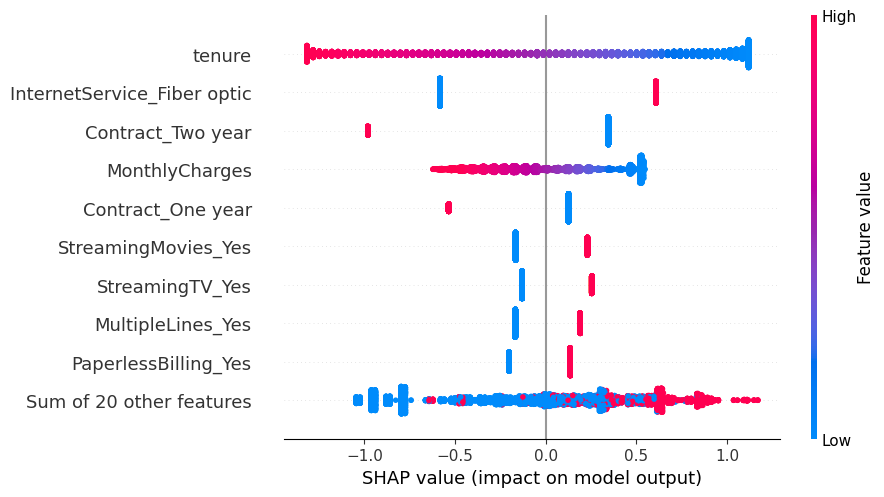

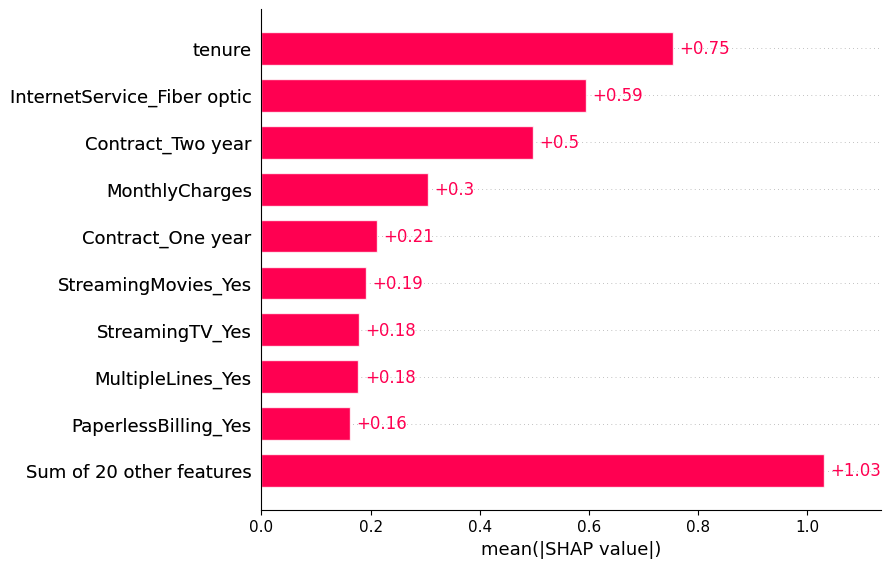

In [ ]:
# =========================
# Model Analysis
# =========================

fi_df = pd.DataFrame(feature_importances)

top_n = 20

top_features = (
    fi_df.mean(axis=1)
    .sort_values(ascending=False)
    .head(top_n)
    .index
)

fi_top = fi_df.loc[top_features]

fi_norm = fi_top.apply(lambda x: x / x.sum(), axis=0)

fig = px.imshow(
    fi_norm,
    color_continuous_scale="Viridis",
    aspect="auto",
    title="Permutation Feature Importance (Normalized)"
)

fig.update_layout(height=700)
fig.show()

driver_strength = fi_norm.mean(axis=1).sort_values(ascending=False)
top_drivers = driver_strength.head(10)

driver_table = top_drivers.reset_index()
driver_table.columns = ["Feature", "Importance"]
def map_driver(feature):
    if "InternetService" in feature:
        return "Service Type Risk"
    if "Contract" in feature:
        return "Contract Stickiness"
    if "PaymentMethod" in feature or "MonthlyCharges" in feature:
        return "Pricing Sensitivity"
    if "tenure" in feature or "TotalCharges" in feature:
        return "Customer Lifecycle"
    if "TechSupport" in feature or "OnlineSecurity" in feature:
        return "Support Engagement"
    return "Other"

driver_table["Category"] = driver_table["Feature"].apply(map_driver)

summary = (
    driver_table
    .groupby("Category")
    .agg(
        Total_Importance=("Importance", "sum"),
        Feature_Count=("Feature", "count")
    )
    .sort_values("Total_Importance", ascending=False)
)
display(driver_table)
display(summary)

# ---------------------------------------------------------
# SHAP
# ---------------------------------------------------------
scaler = best_model.named_steps["scaler"]
lr_model = best_model.named_steps["model"]

feature_names = x_raw.columns.tolist()

x_shap = x_raw.astype(float)
x_scaled = scaler.transform(x_shap)

explainer = shap.LinearExplainer(
    lr_model,
    x_scaled,
    feature_names=feature_names
)

shap_values = explainer(x_scaled)


shap.plots.beeswarm(shap_values)

shap.plots.bar(shap_values)
